<div style="background-color: black; color: white; padding: 10px;text-align: center;">
  <strong>Date Published:</strong> May 28, 2026 <strong>Author:</strong> Adnan Alaref
</div>

# 🧠 BaseLine3_B v2 Pipeline 

## Previous Version

- 🔗 [BaseLine3_B V1 - Volleyball Group Activity Recognition](https://www.kaggle.com/code/adnanalaref/baseline3-b-v1-person-to-scene-pipeline)
  
---

## Team-Aware Player Separation

To better model team interactions in volleyball group activity recognition, players are separated into **left-team** and **right-team** groups before being passed to the network.

Instead of using a fixed image-center split, player assignment is performed using the **median of players' horizontal foot positions (`foot_x`)**. This approach is more stable and robust to camera shifts and outlier player positions.

### Why Median Split?

Earlier experiments using the largest-gap heuristic produced unstable splits such as:

- `11 vs 1`
- `3 vs 9`

because a single isolated player could dominate the split decision.

Using the median-based strategy produces significantly more balanced and realistic team assignments:

- `6 vs 6`
- `5 vs 6`
- `5 vs 5`

which better reflects real volleyball formations.

---

### Team Assignment Strategy

Each detected player is represented using the bottom-center coordinate of the bounding box:

```python
foot_x = x + w / 2

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 1: Import Library.</div>

In [3]:
# !pip uninstall -y torch torchvision torchaudio >/dev/null 2>&1

In [4]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0  >/dev/null 2>&1

In [5]:
# !pip install numpy==1.26.4 pandas==2.2.2 seaborn==0.13.2 --no-cache-dir >/dev/null 2>&1

In [6]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

2.2.0+cu121
12.1
Tesla P100-PCIE-16GB
(6, 0)


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns

print(np.__version__)
print(pd.__version__)
print(sns.__version__)

1.26.4
2.2.2
0.13.2


In [8]:
import re
import os
import cv2
import torch.nn as nn
from pathlib import Path
from pprint import pprint
from tqdm.auto import tqdm
from PIL import Image, ImageOps
from collections import Counter
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import f1_score, classification_report
from typing import Dict, List, TypeVar, Tuple, Any, Callable, Optional

import warnings
warnings.simplefilter(action='ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 2: Collect Group Data From Middle Image.</div>

In [9]:
from google.colab import drive
# drive.mount(r'/content/drive')
dataset_root = r"/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball"
# dataset_root = r"/content/drive/MyDrive/Volleyball_dataset/volleyball_dataset

In [10]:
from collections import OrderedDict
def collect_data(videos_root:str,
                        split_group:List[int]
                        )->OrderedDict[str, Tuple[str, List[Tuple[Tuple[int, int, int, int], str]]]]:
  """
    Collects frame-level annotations from multiple video directories.

    This function iterates over a given list of video IDs, reads their
    corresponding `annotations.txt` files, and builds a mapping between
    each frame's full file path and its group activity label.

    Args:
        videos_root (str): Path to the root directory containing video folders.
        split_group (List[int]): List of video IDs to process.

    Returns:
        OrderedDict[str, Tuple[str, List[Tuple[Tuple[int,int,int,int], str]]]]:
            Mapping from clip_ID (str) to a tuple containing:
                - group_action (str)
                - list of (bbox, player_action) tuples
    Raises:
        FileNotFoundError: If videos_root or any annotation file does not exist.
  """
  if not os.path.isdir(videos_root):
    raise FileNotFoundError(f"Expected directory does not exist.\nPath: {videos_root}")

  # Initialize ordered dict to store annotations
  videos_annotations:OrderedDict[str, Tuple[str, List[Tuple[Tuple[int, int, int, int], str]]]] = OrderedDict()

  for video_id in split_group:
    # Step 1: Get annotations.txt for each video_id
    video_annot = os.path.join(videos_root, str(video_id), 'annotations.txt')
    if not os.path.isfile(video_annot):
      raise FileNotFoundError(f"Video annotation file does not exist.: \nPath: {video_annot}")

    # Step 2: Read and process each line in the annotation file
    with open(video_annot, mode='r') as file:
      for line in file:
        line = line.strip()
        if not line:
          continue # skip empty lines

        parts = line.split()
        frame_ID, group_action = parts[0], parts[1]

        # Remove file extension to get clip_ID
        clip_ID = re.sub(r'\.[a-zA-Z]+$', '', frame_ID, flags=re.IGNORECASE)
        # Remaining parts contain bbox coordinates + player actions
        data_parts = parts[2:]
        bboxes:List[Tuple[Tuple[int, int, int, int], str]] = []

        # Step 2.1: Parse bboxes and corresponding actions
        # Each bbox has 4 numbers, followed by 1 player_action
        for idx in range(0, len(data_parts), 5):
          player_box = tuple(map(int, data_parts[idx:idx+4]))
          player_action = data_parts[idx + 4]
          bboxes.append((player_box, player_action))

        # Step 3: Store collected data in the OrderedDict
        frame_path = os.path.join(videos_root, str(video_id), clip_ID, frame_ID)
        videos_annotations[frame_path] = (group_action, bboxes)

  return videos_annotations

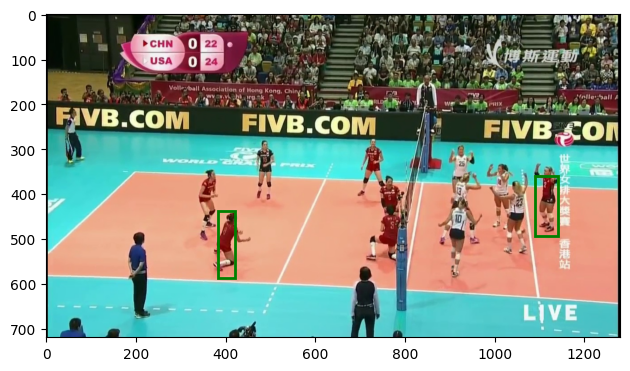

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

players_data = collect_data(os.path.join(dataset_root,'videos'), [0,1])
dd = list(players_data.items())[:2]

# pprint(dd)

img = Image.open(f"{dataset_root}/videos/0/48075/48075.jpg")
x, y, w, h = dd[1][1][1][2][0]
x1, y1, w1, h1 = dd[1][1][1][7][0]
# print(img.size,'\n',"=====================================")

fig, ax = plt.subplots()
ax.imshow(img)
ax.add_patch(patches.Rectangle(
    (x, y), w, h, linewidth=2, edgecolor='g', facecolor='none'
))
ax.add_patch(patches.Rectangle(
    (x1, y1), w1, h1, linewidth=2, edgecolor='g', facecolor='none'
))
plt.tight_layout()
plt.show()

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 3: Create Custom Dateset.</div>

In [12]:
def build_samples(videos_annotations_data:OrderedDict)->List[Tuple[str, str, List[Tuple[int, int, int ,int]]]]:
  samples : List[Tuple[str, str, List[Tuple[int, int, int ,int]]]] = []
  for frame_path, (group_action, players) in videos_annotations_data.items():
    players_boxes = [bbox for bbox, _ in players]
    samples.append((frame_path, group_action, players_boxes))
  return samples

In [13]:
class Group_activity_Dataset(Dataset):
  """
    PyTorch Dataset for group activity recognition from video frames.

    This dataset loads frame-level images from a structured volleyball
    video dataset and find all crops images in this image and return vector
    of crops to model with group activity label.
    Annotations are collected from `annotations.txt` files and converted
    into integer class indices for model training.
  """
  def __init__(self, videos_annotations_data:OrderedDict, transform = None, debug:bool = False) -> None:
    super().__init__()
    self.debug = debug
    self.transform = transform
    self.samples = build_samples(videos_annotations_data)
    self.categorical_Group_labels = [g_label for _, g_label, _ in self.samples]

    # Fixed class list
    Group_activity_clases = [
        "r_set", "r_spike", "r-pass", "r_winpoint", "l_winpoint",
                                     "l-pass", "l-spike", "l_set"
    ]

    self.Group_action2idx = {action:idx for idx, action in enumerate(Group_activity_clases)}
    self.Group_idx2action = {idx:action for action, idx in self.Group_action2idx.items()}

    # Encode labels
    self.labels = [self.Group_action2idx[g_label] for g_label in self.categorical_Group_labels]

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, index:int):
    frame_path, group_action, players_boxes = self.samples[index]
    try:
      with Image.open(frame_path) as image:
        image = ImageOps.exif_transpose(image) # safe, no-op here
        image = image.convert('RGB')
        img_w, img_h = image.size

    except Exception as e:
      raise RuntimeError(f"Warning: Failed to process {frame_path}") from e

    player_info = []
    for box in players_boxes:
      # Important: This assumes COCO format box (x, y, w, h), not (x1,y1,x2,y2).
      x, y, w, h = box

      # 1. validate COCO box
      if w <= 0 or h <= 0:
        print("Bad Box annotation: ", box, "image_id: ", int(os.path.splitext(frame_path)[0]))
        continue

      # 2. convert COCO -> xyxy
      left, top = x, y
      right, bottom = x+w, y+h

      # 3. clamp to image bounds
      left = max(0, min(left, img_w))
      right = max(0, min(right, img_w))
      top = max(0, min(top, img_h))
      bottom = max(0, min(bottom, img_h))

      # 4. final validity check
      if right <= left or bottom <= top:
          continue

      # 5. crop person image
      person_crop = image.crop((left, top, right, bottom))


      # 6. calc bottom-center points for each player
      foot_x = x+w/2

      # 7. apply transform if defined
      if self.transform:
        person_crop = self.transform(person_crop)
      
      # 8. store player info
      player_info.append({
        "foot_x":foot_x,
        "crop":person_crop
      })


    # 9. compute split_x
    xs = np.array([player["foot_x"] for player in player_info])
    split_x = np.median(xs)
    
    # 10. sprate players in left , right
    left_team_crops = []
    right_team_crops = []

    for p in player_info:
      if p["foot_x"] < split_x:
        left_team_crops.append(p["crop"])
      else:
        right_team_crops.append(p["crop"])

    if self.debug:
      print(frame_path, group_action)

    group_label = torch.tensor(self.labels[index], dtype=torch.long)

    return left_team_crops, right_team_crops, group_label

  @property
  def summary(self):
    action_map = dict(Counter(self.categorical_Group_labels))
    print("="*40)
    print(f"Total Images      : {len(self.samples)}")
    print(f"Unique actions    : {len(set(self.categorical_Group_labels))}")
    print("-"*40)
    print("Group actions frequency:")
    for g_action, count in sorted(action_map.items(), key=lambda x:x[1], reverse=True):
      print(f"  {g_action:<10} : {count}")
    print("="*40)

In [14]:
# print("="*50)
# print(frame_path)

# print(f"Left players : {len(left_team_crops)}")
# print(f"Right players: {len(right_team_crops)}")
# print(f"Total        : {len(left_team_crops)+len(right_team_crops)}")

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 4: Experiment Configuration.</div>

In [15]:
from dataclasses import dataclass, field

@dataclass
class ModelConfig:
  # name: TYPE = VALUE
  dropout_a: float = 0.2
  dropout_b: float = 0.5
  group_classes : int = 8
  persons_classes : int = 9
  device: str|None = None
  # mutable → must use field
  train_split:List[int] = field(default_factory=lambda:[
    1, 3, 6, 7, 10, 13, 15, 16, 18, 22, 23, 31,
    32, 36, 38, 39, 40, 41, 42, 48, 50, 52, 53, 54
  ])

  test_split:List[int] = field(default_factory=lambda:[
    4, 5, 9, 11, 14, 20, 21, 25, 29, 34, 35, 37, 43, 44, 45, 47
  ])

  val_split:List[int] = field(default_factory=lambda:[
    0, 2, 8, 12, 17, 19, 24, 26, 27, 28, 30, 33, 46, 49, 51
  ])

  classes_names:List[str] = field(default_factory=lambda:[
      "r_set", "r_spike", "r-pass", "r_winpoint", "l_winpoint", "l-pass", "l-spike", "l_set"
  ])

  def __post_init__(self):
    max_index:int = 54
    if self.device == None:
      self.device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

    # validate splits
    for name, split in {
      "train": self.train_split,
      "test": self.test_split,
      "val": self.val_split,
      }.items():

      # empty
      if len(split) == 0:
        raise ValueError(f"{name}_split cannot be empty.")

      # uniqueness
      if len(split) != len(set(split)):
        raise ValueError(f"{name}_split contains duplicate indices.")

      # range
      if any(idx < 0 or idx > max_index for idx in split):
        raise ValueError(f"{name}_split indices must be in range [0, {max_index}]")

    # data leakage check
    all_index = set(self.train_split) | set(self.val_split) | set(self.test_split)
    if len(all_index) != (len(self.train_split) + len(self.val_split) + len(self.test_split)):
      raise ValueError("Splits overlap, There are data leakage problem!")

@dataclass
class TrainingConfig:
  # Immutable → not use field
  learning_rate: float = 2e-4
  val_bsize:int = 4
  batch_size: int = 4
  epochs: int = 20
  checkpoint_path: str = r'/kaggle/working/chekpoints'
  eta_min: float = 1e-6
  momentum:float = 0.9
  print_every:int = 1
  weight_decay: float = 1e-4
  betas: tuple = (0.9, 0.999)

model_config = ModelConfig()
train_config = TrainingConfig()

In [16]:
def save_checkpoints(model: nn.Module, scaler: torch.cuda.amp.GradScaler|None,
                     optimizer: torch.optim.Optimizer, train_loss: float, val_loss: float, macro_f1: float, epoch: int, path: str)->None:
  # Define Chekpoint
  checkpoint = {
    "epoch": epoch,
    "macro_f1":float(macro_f1),
    "val_loss": float(val_loss),
    "train_loss": float(train_loss),
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
  }

  # add scaler ONLY if it exists
  if scaler is not None:
    checkpoint['scaler_state_dict'] = scaler.state_dict()

  # Create dir
  os.makedirs(os.path.dirname(path), exist_ok=True)
  torch.save(checkpoint, path)
  print(f"Saved checkpoint: {path}")


def load_checkpoint(path:str, device: str|None=None)->dict:
  if not os.path.isfile(path):
    raise FileNotFoundError(f"Checkpoint file does not found.\nPath: {path}")

  # Load Data
  checkpoint_data = torch.load(path, map_location=device)
  return checkpoint_data

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 5: Dataset and DataLoader Setup.</div>

In [17]:
def custom_collate_fn(batch)-> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
  """
    Custom collate function for batching variable-number player crops
    in group activity recognition tasks.

    This function handles samples where each image contains a different
    number of detected players. It pads all samples in the batch to the
    maximum number of players and stacks them into fixed-size tensors.

    Each sample in `batch` is expected to be:
      (
            l_crops: List[Tensor]  # player crops from left team
            r_crops: List[Tensor]  # player crops from right team
            label: Tensor or int   # group activity label
      )

    Args:
        batch (List[Tuple[List[Tensor], List[Tensor], Tensor]]):
            A batch of dataset samples.

    Returns:
        Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
            left_team:
                Tensor of shape [B, max_left_players, C, H, W]
            right_team:
                Tensor of shape [B, max_right_players, C, H, W]
            labels:
                Tensor of shape [B] containing class indices
  """
  B = len(batch)
  l_list, r_list, labels = zip(*batch)
  max_left = max(len(left) for left in l_list)
  max_right = max(len(right) for right in r_list)

  # infer shape safely
  first_left = batch[0][0][0]
  C, H, W = first_left.shape

  left_team = torch.zeros(B, max_left, C, H, W)
  right_team = torch.zeros(B, max_right, C, H, W)

  for i, (l_crops, r_crops, _) in enumerate(batch):
    # Because i return list of crops from custom dataset
    # So i need to convert from list to one tensor first
    left_team[i, :len(l_crops)] = torch.stack(l_crops)
    right_team[i, :len(r_crops)] = torch.stack(r_crops)

  labels = torch.stack(labels)
  return left_team, right_team, labels

In [18]:
import torchvision.transforms as T
# Perpare Data Augmentation
train_transform = T.Compose([
    T.Resize(256),              # keep aspect ratio
    T.CenterCrop(224),          # stable spatial structure
    T.RandomRotation(3),        # small realism noise
    T.ColorJitter(0.2, 0.2, 0.2, 0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Path to the videos directory inside the dataset
videos_root = os.path.join(dataset_root,'videos')

# Number of worker processes used for data loading
# > 0 enables parallel data loading
num_workers = min(4, os.cpu_count() or 1)

# Pin memory is only useful when training on CUDA
# It speeds up CPU → GPU memory transfers
pin_memory = model_config.device == "cuda"

loader_kwargs = dict(
  num_workers = num_workers,
  pin_memory = pin_memory,
  persistent_workers = num_workers > 0,
  # persistent_workers Keeps worker processes alive between epochs
  # Must be False when num_workers == 0
)

# prefetch_factor controls how many batches each worker preloads
# It is only valid when num_workers > 0
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = 2

# Training dataset (uses training split indices, no shuffling)
videos_annotations_train_data = collect_data(videos_root, model_config.train_split)
train_dataset = Group_activity_Dataset(videos_annotations_train_data, train_transform)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=train_config.batch_size,
                          shuffle=True,
                          collate_fn=custom_collate_fn,
                          **loader_kwargs)

# Validation dataset (no data augmentation, no shuffling)
videos_annotations_val_data = collect_data(videos_root, model_config.val_split)
val_dataset = Group_activity_Dataset(videos_annotations_val_data, val_transform)

val_loader = DataLoader(dataset=val_dataset,
                        batch_size=train_config.val_bsize,
                        shuffle=False,
                        collate_fn=custom_collate_fn,
                        **loader_kwargs)

# Test dataset (used only for final evaluation)
videos_annotations_test_data = collect_data(videos_root, model_config.test_split)
test_dataset = Group_activity_Dataset(videos_annotations_test_data, val_transform)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=train_config.val_bsize,
                         collate_fn=custom_collate_fn,
                         shuffle=False,
                         **loader_kwargs)

In [19]:
left, right, labels = next(iter(train_loader))
left.shape, right.shape, labels.shape

(torch.Size([4, 6, 3, 224, 224]),
 torch.Size([4, 6, 3, 224, 224]),
 torch.Size([4]))

In [20]:
print(len(train_loader))
train_dataset.summary

538
Total Images      : 2152
Unique actions    : 8
----------------------------------------
Group actions frequency:
  l-pass     : 378
  r-pass     : 353
  l_set      : 304
  l-spike    : 289
  r_set      : 283
  r_spike    : 261
  l_winpoint : 161
  r_winpoint : 123


In [21]:
print(len(val_loader))
val_dataset.summary

336
Total Images      : 1341
Unique actions    : 8
----------------------------------------
Group actions frequency:
  r-pass     : 238
  l-pass     : 222
  r_spike    : 189
  l-spike    : 174
  r_set      : 169
  l_set      : 160
  l_winpoint : 104
  r_winpoint : 85


In [22]:
print(len(test_loader))
test_dataset.summary

335
Total Images      : 1337
Unique actions    : 8
----------------------------------------
Group actions frequency:
  l-pass     : 226
  r-pass     : 210
  r_set      : 192
  l-spike    : 179
  r_spike    : 173
  l_set      : 168
  l_winpoint : 102
  r_winpoint : 87


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6: Model Architecture Design.</div>

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.1: Build Model_A Architecture Design.</div>

In [23]:
class ExtendBaseLine2_a(nn.Module):
  def __init__(self, backbone:nn.Module, num_features:int, num_classes:int, prop_dropout:float) -> None:
    super().__init__()
    self.backbone = backbone
    self.conv_layer = nn.Sequential(
      nn.Conv2d(num_features, num_classes, kernel_size=1),
      nn.Dropout2d(prop_dropout),
      nn.AdaptiveAvgPool2d((1, 1))
    )

  def forward(self, x:torch.Tensor)->torch.Tensor:
    x = self.backbone(x)
    x = self.conv_layer(x)
    x = torch.flatten(x, 1)
    return x

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.2: Create Instance From Model_A.</div>

In [24]:
Weights = models.ResNet50_Weights.DEFAULT
orignal_model = models.resnet50(weights = Weights)
layers = list(orignal_model.children())[:-2]
truncated_model = nn.Sequential(*layers)
with torch.no_grad():
  dummy_data = torch.zeros((1,3,224,224))
  num_features = truncated_model(dummy_data).shape[1]

BaseLine2a_model = ExtendBaseLine2_a(truncated_model, num_features, model_config.persons_classes, model_config.dropout_a)

In [25]:
try:
  import torchinfo
  print(f"trochinfo version: {torchinfo.__version__}")
except:
  !pip install torchinfo >/dev/null 2>&1
  import torchinfo
  print(f"torchinfo version: {torchinfo.__version__}")

dummy_data_test = torch.zeros((1,3,224,224))
torchinfo.summary(model= BaseLine2a_model.to("cpu"),
                  input_data=dummy_data_test, 
                  device = "cpu")

trochinfo version: 1.8.0


Layer (type:depth-idx)                        Output Shape              Param #
ExtendBaseLine2_a                             [1, 9]                    --
├─Sequential: 1-1                             [1, 2048, 7, 7]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [1, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [1, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [1, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [1, 512, 28, 28]          379,392

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.3: Load Weights From Pretrained Model(Model A) For Specific Layers (only backbone).</div>

In [26]:
# 1. Load State dictionary
ckpt = load_checkpoint(path = "/kaggle/input/models/adnanalaref/baseline2-a/pytorch/default/1/checkpoint_epoch25.pt", device = model_config.device)
state_dict = ckpt['model_state_dict']

# 2. Load weights
BaseLine2a_model.load_state_dict(state_dict, strict=False)

# 3. Extract backbone and we will pass it as backbone for Model B.
feature_extractor = BaseLine2a_model.backbone

## Step 6.4: Test Feature_Extactor Output Shape Must [B,2048,7,7] .

In [27]:
dummy_data = torch.zeros((1,3,224,224))
feature_extractor(dummy_data).shape

torch.Size([1, 2048, 7, 7])

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.5: Build Model_B Architecture Design.</div>

**[B,3,H,W] → Backbone → [B,2048,7,7] → MaxPool2d(2,2) → [B,2048,3,3] → Flatten → [B,18432] → Linear → [B,512] → Classifier**

In [28]:
class ExtendBaseLine2_b(nn.Module):
  def __init__(self, backbone: nn.Module, num_features:int, num_classes:int, prop_dropout:float) -> None:
    super().__init__()
    self.backbone = backbone   # [B, 2048, 7, 7]
    self.adaptivepool = nn.AdaptiveAvgPool2d((1,1)) # [B, 2048, 1, 1]

    self.classifier = nn.Sequential(          #[B,N]
      nn.Linear(num_features * 2 , 512),
      nn.BatchNorm1d(512),
      nn.ReLU(),
      nn.Dropout(prop_dropout),
      nn.Linear(512,num_classes)
    )

  def forward(self, left_team:torch.Tensor, right_team:torch.Tensor):
    # [B,N,C,H,W] → [B*N,C,H,W]
    B, N_l, C, H, W = left_team.shape
    _, N_r, _, _, _ = right_team.shape

    left = left_team.reshape(B*N_l, C, H, W)
    right = right_team.reshape(B*N_r, C, H, W)
    # [B*N,C,H,W]

    left = self.backbone(left)
    right = self.backbone(right)
    # [B*N, F, 7, 7]

    left = self.adaptivepool(left)
    right = self.adaptivepool(right)
    # [B*N, F, 1, 1]

    left = torch.flatten(left, 1)
    right = torch.flatten(right, 1)
    # [B*N, F]

    # reshape back to (B, N, F)
    left = left.reshape(B, N_l, -1)
    right = right.reshape(B, N_r, -1)

    # team aggregation , return (values, indices)
    left = left.max(dim=1).values
    right = right.max(dim=1).values
    # [B,F]

    final_feature = torch.cat([left, right], dim=1)
    logits = self.classifier(final_feature)
    # [B,8]
    return logits

In [29]:
criterion = nn.CrossEntropyLoss()
BaseLine2b_model = ExtendBaseLine2_b(backbone = feature_extractor,
                                     num_features = num_features,
                                     num_classes  = model_config.group_classes,
                                     prop_dropout = model_config.dropout_b)

optimizer = torch.optim.AdamW(params = BaseLine2b_model.parameters(),
                              lr = train_config.learning_rate,
                              betas = train_config.betas,
                              weight_decay = train_config.weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer = optimizer,
                                                       T_max = train_config.epochs,
                                                       eta_min = train_config.eta_min)

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.6: Model_B Architecture Summary.</div>

In [30]:
left_dummy_data = torch.zeros((1,5,3,224,224))
right_dummy_data = torch.zeros((1,4,3,224,224))
torchinfo.summary(model= BaseLine2b_model, input_data=[left_dummy_data, right_dummy_data], device = model_config.device)

Layer (type:depth-idx)                        Output Shape              Param #
ExtendBaseLine2_b                             [1, 8]                    --
├─Sequential: 1-1                             [5, 2048, 7, 7]           --
│    └─Conv2d: 2-1                            [5, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [5, 64, 112, 112]         128
│    └─ReLU: 2-3                              [5, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [5, 64, 56, 56]           --
│    └─Sequential: 2-5                        [5, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [5, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [5, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [5, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [5, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [5, 512, 28, 28]          379,392

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 7: Training and Testing Pipeline.</div>

In [31]:
import random
import numpy as np

def set_all_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
      
    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)

In [32]:
def accuracy_fn(logits: torch.Tensor, targets: torch.Tensor)->Tuple[int, int]:
  """
    Calculates the number of correct predictions and batch size.

    Args:
        logits (torch.Tensor): Raw model outputs, shape (B, num_classes)
        targets (torch.Tensor): Ground truth labels, shape (B,)

    Returns:
        Tuple[int, int]:
            - batch_correct: number of correct predictions in this batch
            - batch_size: number of samples in this batch
  """
  preds = logits.argmax(dim=1)  # Go from logits -> pred labels
  batch_correct = (preds == targets).sum().item()
  batch_size = targets.size(0)
  return batch_correct, batch_size

In [33]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               accuracy_fn: Callable[[torch.Tensor, torch.Tensor], Tuple[int, int]],
               criterion : torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               scaler: torch.cuda.amp.GradScaler,
               device: str
              )-> dict[str, float, float]:

  total_train_loss, total_correct = 0.0, 0
  total_samples = 0

  model.to(device)
  model.train()

  for left_crops, right_crops, targets in dataloader:
    
    targets = targets.to(device, non_blocking=True)
    left_crops = left_crops.to(device, non_blocking=True)
    right_crops = right_crops.to(device, non_blocking=True)

    optimizer.zero_grad(set_to_none=True) # faster & safer

    # Forward pass
    with autocast():
      logits = model(left_crops, right_crops)
      per_sample_loss = criterion(logits, targets)
      loss = per_sample_loss.sum()

    # Backward with scaled loss
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Accumulate loss
    total_train_loss += per_sample_loss.sum().item()

    # Calculate batch accuracy
    batch_correct, batch_size = accuracy_fn(logits=logits, targets= targets)
    total_correct +=batch_correct
    total_samples +=batch_size


  # Compute epoch-level average loss and accuracy
  avg_loss = total_train_loss/total_samples  # average batch loss
  avg_acc = (total_correct / total_samples) * 100  # true epoch accuracy in %

  return {
    "Model_name": model.__class__.__name__,
    "Train_loss": avg_loss,
    "Train_acc": avg_acc
  }

In [34]:
def eval_step(model:torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              accuracy_fn: Callable[[torch.Tensor, torch.Tensor], Tuple[int, int]],
              criterion: torch.nn.Module,
              device: str
             )-> dict[str, float, float]:

  total_eval_loss, total_correct = 0.0, 0
  all_targets, all_preds = [], []
  total_samples = 0

  model.to(device)
  model.eval()

  with torch.inference_mode():
    for l_crops, r_crops, targets in dataloader:
        
      l_crops = l_crops.to(device, non_blocking=True)
      r_crops = r_crops.to(device, non_blocking=True)
      targets = targets.to(device, non_blocking=True)

      with autocast(dtype=torch.float16):
        eval_logits = model(l_crops, r_crops)
        per_sample_loss = criterion(eval_logits, targets)
        loss = per_sample_loss.sum()

      # Loss
      total_eval_loss += per_sample_loss.sum().item()

      # Accuracy
      batch_correct, batch_size = accuracy_fn(logits= eval_logits, targets= targets)
      total_correct += batch_correct
      total_samples += batch_size

      # Store predictions and targets for metrics like F1 (Note: F1 work only with numpy array or tensors on CPU)
      eval_preds = eval_logits.argmax(dim=1)  # Go from logits -> pred labels
      all_preds.append(eval_preds.detach().cpu()) # .detach() remove gradient tracking , moves data from GPU to CPU
      all_targets.append(targets.detach().cpu())

    avg_loss = total_eval_loss / total_samples
    eval_acc = (total_correct / total_samples) * 100

    # Concatenate all predictions and targets
    y_preds = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()
    macro_f1 = f1_score(y_true, y_preds, average="macro")

    return {
      "Model_name": model.__class__.__name__,
      "Eval_loss": avg_loss,
      "Eval_acc": eval_acc,
      "Macro_f1": macro_f1
    }

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 8: Training and Validation Model With Mixed Precision.</div>

In [35]:
from torch.cuda.amp import  GradScaler # PERFORMANCE OPTIMIZATIONS
scaler = GradScaler()  # helps scale gradients safely

set_all_seeds(42)
train_history, val_history = {}, {}
train_acc_values, val_acc_values, macro_f1_values = [], [], []
epoch_values, val_losses_values, train_losses_values, lr_history = [], [], [], []

best_macro_f1 = 0.0
for epoch in range(train_config.epochs):
  # Train → Validate → Compute Macro F1 → Save if best → Scheduler step

  # ---- Train ----
  train_history = train_step(model= BaseLine2b_model,
                             dataloader= train_loader,
                             accuracy_fn= accuracy_fn,
                             criterion= criterion,
                             optimizer= optimizer,
                             scaler= scaler,
                             device= model_config.device)


  # ---- Validate ----
  val_history = eval_step(model= BaseLine2b_model,
                          dataloader = val_loader,
                          accuracy_fn= accuracy_fn,
                          criterion= criterion,
                          device= model_config.device)


   # ---- Logging ----
  train_losses_values.append(train_history['Train_loss'])
  train_acc_values.append(train_history['Train_acc'])

  val_losses_values.append(val_history['Eval_loss'])
  val_acc_values.append(val_history['Eval_acc'])

  lr_history.append(optimizer.param_groups[0]['lr'])
  macro_f1_values.append(val_history['Macro_f1'])
  epoch_values.append(epoch)

  # ---- Checkpoint ----
  if val_history["Macro_f1"] > best_macro_f1:
    best_macro_f1 = val_history["Macro_f1"]
    save_checkpoints(BaseLine2b_model,
                     scaler, optimizer,
                     train_history["Train_loss"],
                     val_history["Eval_loss"],
                     best_macro_f1, epoch+1,
                     os.path.join(train_config.checkpoint_path, f"checkpoint_epoch{epoch+1}.pt"))

  # ---------- SCHEDULER ----------
  scheduler.step() # CosineAnnealingLR check per epoch or batch,  ALWAYS after validation

  # ---- Print ----
  if(epoch+1) % train_config.print_every == 0:
    print(f"Epoch [{epoch+1:>2}] - Macro F1: {val_history['Macro_f1']:.3f} | Train loss: {train_history['Train_loss']:.3f} | Train acc: {train_history['Train_acc']:.3f}% | Eval loss: {val_history['Eval_loss']:.3f} | Eval acc: {val_history['Eval_acc']:.3f}% | LR: {scheduler.get_last_lr()[0]:.6f}")

Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch1.pt
Epoch [ 1] - Macro F1: 0.580 | Train loss: 0.378 | Train acc: 45.586% | Eval loss: 0.297 | Eval acc: 58.762% | LR: 0.000199
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch2.pt
Epoch [ 2] - Macro F1: 0.662 | Train loss: 0.271 | Train acc: 61.896% | Eval loss: 0.252 | Eval acc: 65.623% | LR: 0.000195
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch3.pt
Epoch [ 3] - Macro F1: 0.665 | Train loss: 0.235 | Train acc: 68.866% | Eval loss: 0.247 | Eval acc: 65.846% | LR: 0.000189
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch4.pt
Epoch [ 4] - Macro F1: 0.679 | Train loss: 0.192 | Train acc: 75.046% | Eval loss: 0.241 | Eval acc: 67.040% | LR: 0.000181
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch5.pt
Epoch [ 5] - Macro F1: 0.716 | Train loss: 0.152 | Train acc: 81.273% | Eval loss: 0.222 | Eval acc: 70.172% | LR: 0.000171
Saved checkpoint: /kaggle/working/chekpoints/check

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 9: Evaluate Model.</div>

In [36]:
model = ExtendBaseLine2_b(backbone=feature_extractor, 
                          num_features= num_features,
                          num_classes = model_config.group_classes,
                          prop_dropout= model_config.dropout_b
                         )

ckpt = load_checkpoint(path = r"/kaggle/working/chekpoints/checkpoint_epoch13.pt", device=model_config.device)
model.load_state_dict(ckpt['model_state_dict'])

<All keys matched successfully>

In [37]:
Model_result = eval_step(model, test_loader, accuracy_fn, criterion, model_config.device)
Model_result

{'Model_name': 'ExtendBaseLine2_b',
 'Eval_loss': 0.18715955592307387,
 'Eval_acc': 77.03814510097232,
 'Macro_f1': 0.7802478182616019}

In [38]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              device: str
              )-> Tuple[np.ndarray, np.ndarray]:
  """
    Runs model evaluation and generates predictions on a dataset.

    Performs a forward-only pass in inference mode, collects predicted
    class labels and ground-truth targets, and returns them as tensors
    on the CPU for further metric computation(classification_report).

    Args:
        model (nn.Module): Trained model to be evaluated.
        dataloader (DataLoader): Iterable over evaluation batches.
        device (str): Device used for inference ('cuda' or 'cpu').

    Returns:
        Tuple[ndarray, ndarray]:: Ground-truth labels and predicted labels,
        both concatenated into CPU tensors then convert to ndarray.
  """
  y_true, y_preds = [], []
    
  model.eval()
  with torch.inference_mode():
    for X_left, X_right, y in dataloader:
        
      y = y.to(device, non_blocking=True)
      X_left = X_left.to(device, non_blocking=True)
      X_right = X_right.to(device, non_blocking=True)
 
      logits = model(X_left, X_right)  # return -> [B,num_classes]
      preds = logits.argmax(dim=1)

      y_preds.append(preds.cpu())
      y_true.append(y.cpu())

    y_preds_tensor = torch.cat(y_preds).numpy()
    y_true_tensor = torch.cat(y_true).numpy()

  return y_true_tensor, y_preds_tensor

y_true, y_preds = test_step(model, test_loader, model_config.device)

In [39]:
def display_train_eval_curves(epochs:List[int],
                              train_losses:List[float],
                              val_losses:List[float], 
                              train_acc:List[float], 
                              val_acc:list[float])->None:
  """
    Plots training and testing loss curves over epochs.

    Args:
        epochs (list or array-like): Epoch numbers.
        train_losses (list or array-like): Training loss values per epoch.
        test_losses (list or array-like): Testing/validation loss values per epoch.

    Returns:
        None: Displays a matplotlib figure showing the loss curves.
  """

  plt.figure(figsize = (12,5), dpi = 100)

  # -------- Loss Curves --------  
  plt.subplot(1,2,1)
  plt.plot(epochs, train_losses, label = "Train Loss")
  plt.plot(epochs, val_losses, label = "val Loss")
  plt.ylabel("Loss", fontsize= 12, weight='bold')
  plt.xlabel("Epochs", fontsize= 12, weight='bold')
  plt.title("Training and Validation Loss", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  # -------- Accuracy Curves --------
  plt.subplot(1,2,2)
  plt.plot(epochs,train_acc,label = "Train acc")
  plt.plot(epochs ,val_acc, label = "val acc")
  plt.ylabel("Accuracy" ,fontsize = 12 ,weight='bold')
  plt.xlabel("Epochs" ,fontsize = 12 ,weight='bold')
  plt.title("Training and Validation Accuracy", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  plt.tight_layout()
  # plt.axis("off")
  plt.show()


def display_Classification_Report(y_true:np.ndarray, y_pred:np.ndarray, classes_names:List[str])->None:
  # Generate the classification report
  report = classification_report(y_true = y_true, y_pred= y_pred, target_names= classes_names)
  print(f"Classification Report:\n{report}")

In [40]:
def display_macrof1_curve(epoch_values: List[int],
                          macro_f1_values: List[float], 
                          save_path: Optional[str] = None, show: bool = True)->None:  
  plt.figure(figsize=(10,5) ,dpi=100)

  # -------- Loss Curves --------
  plt.subplot(1,2,1)
  plt.plot(
    epoch_values,
    macro_f1_values,
    color='orange',
    marker="o",
    linewidth=2,
    label="Macro F1"
  )

  plt.title("Macro F1 Values Over Epochs", fontsize=12, weight="bold")
  plt.ylabel("Macro F1", fontsize=12, weight="bold")
  plt.xlabel("Epochs", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  plt.tight_layout()
  # ---- Save ----
  if save_path is not None:
     os.makedirs(os.path.dirname(save_path), exist_ok=True)
     plt.savefig(save_path, dpi=300, bbox_inches="tight")

  if show:
     plt.show()
  else:
     plt.close(fig)

In [41]:
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1])>=19, "mlxtend verison should be 0.19.0 or higher"

except Exception as e:
  ! pip install torchmetrics > /dev/null 2>&1 && pip install -U mlxtend >/dev/null 2>&1
  import torchmetrics, mlxtend

  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [42]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
def display_Confusion_matrix(y_true: np.ndarray, y_preds:np.ndarray, classes_names:List[str])-> None:
  """
    Plots a multiclass confusion matrix using torchmetrics and mlxtend.
    
    Args:
        y_true (np.ndarray): Ground-truth labels (shape: [N])
        y_preds (np.ndarray): Predicted labels (shape: [N])
        classes_names (List[str]): Class names for each label index

    Returns:
        None: Displays a matplotlib confusion matrix .
    """
  
  # Convert NumPy arrays → Torch tensors (required by torchmetrics)
  y_true = torch.tensor(y_true)
  y_preds = torch.tensor(y_preds)

  # Initialize confusion matrix for multiclass classification
  confmat = ConfusionMatrix(task='multiclass', 
                            num_classes=len(classes_names)
  )

  # Compute confusion matrix (returns a torch tensor
  confmat_tensor = confmat(preds= y_preds, target= y_true)

  # Convert tensor → NumPy array for plotting with mlxtend
  confmat_numpy_array =confmat_tensor.cpu().numpy()

  # Plot confusion matrix
  fig, ax = plot_confusion_matrix(conf_mat = confmat_numpy_array, 
                                  class_names= classes_names,
                                  figsize = (10,5))
  plt.tight_layout()
  plt.show()

In [43]:
display_Classification_Report(y_true, y_preds, model_config.classes_names)

Classification Report:
              precision    recall  f1-score   support

       r_set       0.84      0.65      0.73       192
     r_spike       0.79      0.87      0.83       173
      r-pass       0.65      0.82      0.73       210
  r_winpoint       0.82      0.83      0.82        87
  l_winpoint       0.85      0.86      0.85       102
      l-pass       0.80      0.64      0.71       226
     l-spike       0.80      0.87      0.83       179
       l_set       0.74      0.74      0.74       168

    accuracy                           0.77      1337
   macro avg       0.79      0.78      0.78      1337
weighted avg       0.78      0.77      0.77      1337



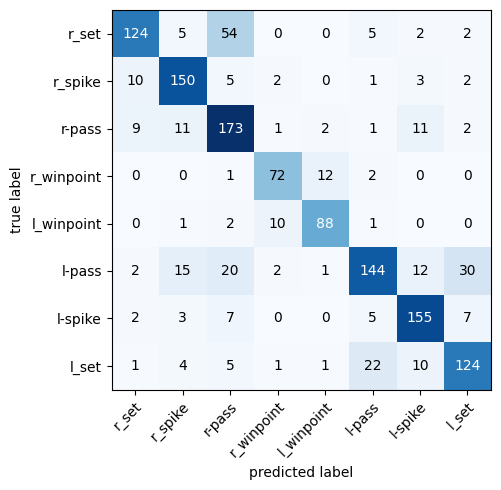

In [44]:
display_Confusion_matrix(y_true, y_preds, model_config.classes_names)

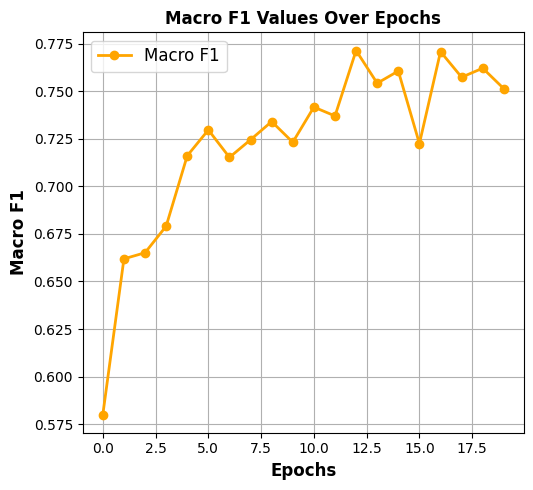

In [45]:
display_macrof1_curve(epoch_values,
                      macro_f1_values, 
                      r"/kaggle/working/Figures")

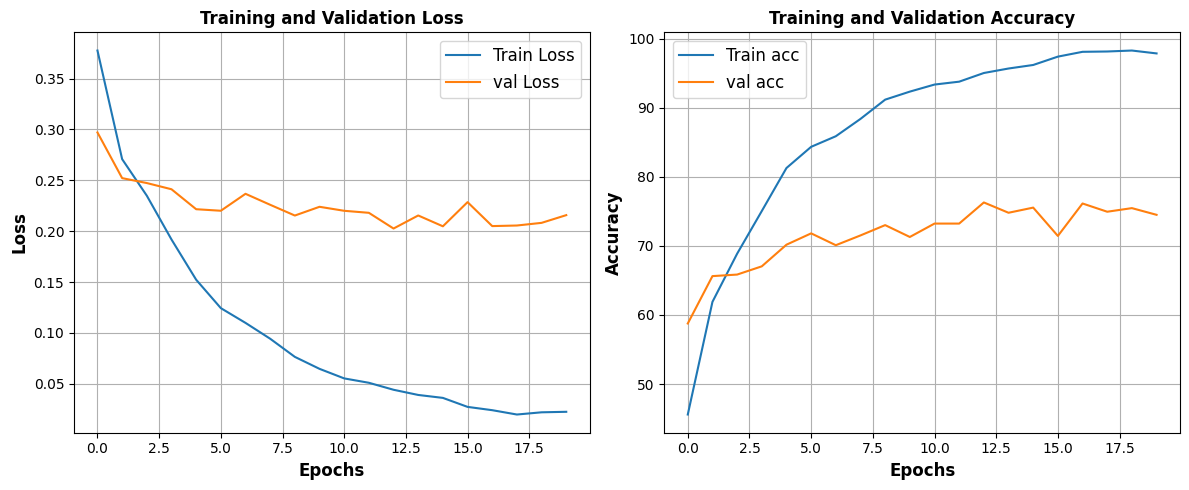

In [46]:
display_train_eval_curves(epoch_values,
                          train_losses_values, 
                          val_losses_values,
                          train_acc_values, val_acc_values)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Thanks & Upvote ❤️</div>